# Financial News Summarizer Models

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("../data/financial_news.csv")

In [3]:
df.isnull().sum()

Date                   0
Subject                0
Content                0
ParaphrasedSubject     0
CompactedSummary      28
DetailedSummary       43
Impact                44
dtype: int64

In [4]:
# We will only use Content and CompactedSummary columns so we clean only those
df = df.dropna(subset=['Content', 'CompactedSummary'])

In [5]:
df = df.reset_index(drop=True)

In [6]:
df.shape

(1811, 7)

In [7]:
df.isnull().sum()

Date                   0
Subject                0
Content                0
ParaphrasedSubject     0
CompactedSummary       0
DetailedSummary       15
Impact                42
dtype: int64

In [8]:
df.shape

(1811, 7)

### Visualization

In [9]:
df.head()

,Date,Subject,Content,ParaphrasedSubject,CompactedSummary,DetailedSummary,Impact
0,3-Mar-24,BAWAN,Bawan Co. announces the board of director’s de...,Bawan Co. Declares Cash Dividends for Second H...,Bawan Co. announces the distribution of cash d...,Bawan Co. has announced its board of directors...,Shareholders who meet the eligibility criteria...
1,3-Mar-24,SABIC AGRI-NUTRIENTS,Addendum Announcement from SABIC Agri-Nutrient...,SABIC Agri-Nutrients Company Extends MoU with ...,SABIC Agri-Nutrients Company and Saudi Agricu...,SABIC Agri-Nutrients Company has announced an...,The extension of the MoU between SABIC Agri-N...
2,3-Mar-24,GAS,Gas Arabian Services Co. Announces Contract Si...,GAS Arabian Services Co. Inks Contract with Sa...,GAS Arabian Services Co. has signed a contrac...,GAS Arabian Services Company has announced the...,This contract marks a significant milestone fo...
3,3-Mar-24,GAS,Gas Arabian Services Co. Announces Contract Si...,GAS Arabian Services Co. Inks Contract with Sa...,GAS Arabian Services Co. has signed a contrac...,GAS Arabian Services Company has announced the...,This contract marks a significant milestone fo...
4,3-Mar-24,ADVANCED,ADVANCED PETROCHEMICAL COMPANY ANNOUNCES THE L...,Advanced Petrochemical Company Resumes Propyle...,Advanced Petrochemical Company has resumed op...,Advanced Petrochemical Company has announced t...,The resumption of operations at Advanced Petro...


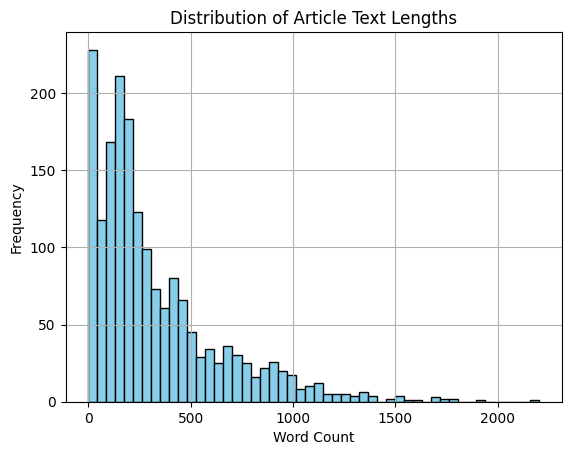

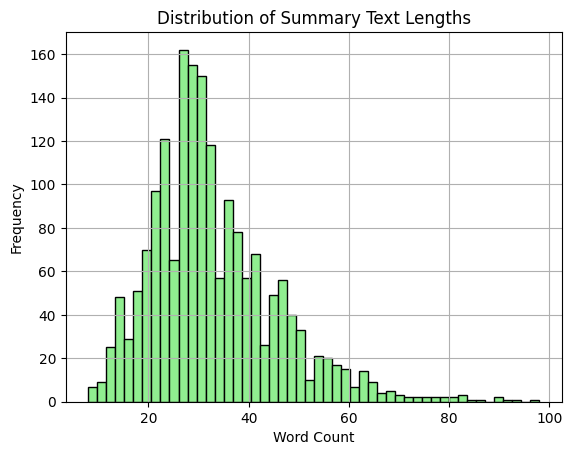

In [10]:
import matplotlib.pyplot as plt

# Plot the distribution of article lengths
text_lengths = df['Content'].apply(lambda x: len(x.split()))
summary_lengths = df['CompactedSummary'].apply(lambda x: len(x.split()))

plt.figure()
text_lengths.hist(bins=50, color='skyblue', edgecolor='black')
plt.title('Distribution of Article Text Lengths')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.show()

plt.figure()
summary_lengths.hist(bins=50, color='lightgreen', edgecolor='black')
plt.title('Distribution of Summary Text Lengths')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.show()

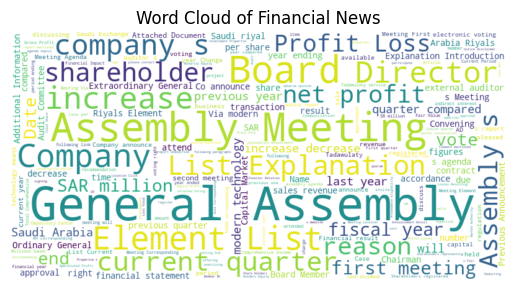

In [ ]:
from wordcloud import WordCloud

# Combine all content into a single string to view it in the word cloud
all_content = " ".join([text for text in df['Content']])

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_content)

plt.figure()
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud of Financial News")
plt.show()

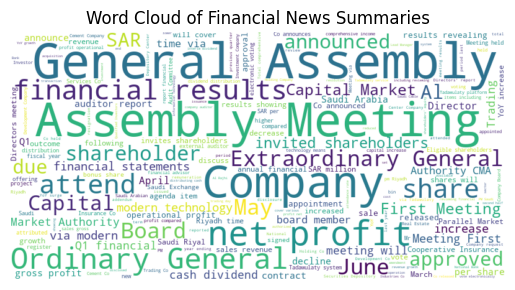

In [12]:
summary_content = " ".join([text for text in df['CompactedSummary']])
summary_wordcloud = WordCloud(width=800, height=400, background_color='white').generate(summary_content)

plt.figure()
plt.imshow(summary_wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud of Financial News Summaries")
plt.show()

In [ ]:
print(f"Content: \n {df['Content'].iloc[0]}\n")
print("-"*150)
print(f"Compacted Summary: \n {df['CompactedSummary'].iloc[0]}\n")
print("-"*150)
print("Detailed Summary: \n", df['DetailedSummary'].iloc[0], "\n")

Content: 
 Bawan Co. announces the board of director’s decision to distribute cash dividends for the second half of the year 2023  Element List Explanation
Introduction Bawan Co. announces the board of director’s decision to distribute cash dividends for the second half of the year 2023
Date of the board’s decision 2024-02-29 Corresponding to 1445-08-19
The Total amount distributed 51 million
Number of Shares Eligible for Dividends 60 million shares
Dividend per share 0.85
Percentage of Dividend to the Share Par Value (%) 8.5 %
Eligibility date The entitlement shall be for the shareholders who own the shares at the close of trading on April 3, 2024 and as per the shareholders register in Securities Depository Center (Edaa) at the end of the 2nd trading day following the entitlement date.
Distribution Date April 29, 2024
The name of other official authorities and the details of their non-refusal to the recommendation or decision Not applicable
Additional Information The Company urges it

# Pre processing our dataset

In [ ]:
from bs4 import BeautifulSoup
import re

### Cleaning text

In [23]:
def clean_text(text):
    # Remove HTML tags, links, and multiple spaces
    text = BeautifulSoup(text, "html.parser").get_text()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'\s{2,}', ' ', text)

    return text.strip()

In [24]:
df['Content'] = df['Content'].apply(clean_text)
df['CompactedSummary'] = df['CompactedSummary'].apply(clean_text)

C:\Users\Raj\AppData\Local\Temp\ipykernel_7928\1913819.py:3: MarkupResemblesLocatorWarning: The input looks more like a filename than markup. You may want to open this file and pass the filehandle into Beautiful Soup.
  text = BeautifulSoup(text, "html.parser").get_text()


### Tokenization

In [25]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [26]:
# Tokenizer for the input texts (Context data)
input_tokenizer = Tokenizer(oov_token="<OOV>")
input_tokenizer.fit_on_texts(df['Content'])

# Tokenizer for the output texts (Summary data)
output_tokenizer = Tokenizer(oov_token="<OOV>")
output_tokenizer.fit_on_texts(df['CompactedSummary'])

In [29]:
print(input_tokenizer.word_index)
print(output_tokenizer.word_index)

{'<OOV>': 1, 'the': 2, 'of': 3, 'to': 4, 'and': 5, 'in': 6, 'for': 7, 'on': 8, 'meeting': 9, 'general': 10, 'year': 11, 'company': 12, 'a': 13, 'is': 14, '2024': 15, 'board': 16, 'by': 17, 'quarter': 18, 'shareholders': 19, 'assembly': 20, 'at': 21, 'increase': 22, 'be': 23, 'from': 24, 'with': 25, 'saudi': 26, 'financial': 27, 'al': 28, '2023': 29, 'profit': 30, 'current': 31, '1': 32, 'as': 33, 'previous': 34, 'voting': 35, 'corresponding': 36, 'will': 37, 'its': 38, 'directors': 39, 'date': 40, 'list': 41, 'element': 42, 'sar': 43, 'compared': 44, 'capital': 45, 'during': 46, 'shares': 47, 'that': 48, 'which': 49, '31': 50, 'are': 51, 'million': 52, 'mr': 53, 'period': 54, 'net': 55, 'an': 56, '1445': 57, '2': 58, 'first': 59, 'or': 60, '12': 61, 'riyals': 62, 'decrease': 63, 'company’s': 64, 'announces': 65, 'all': 66, '000': 67, 'end': 68, 'explanation': 69, 'share': 70, 'loss': 71, 'agenda': 72, 'announcement': 73, '3': 74, "assembly's": 75, 'assembly’s': 76, 'co': 77, 'vote': 78

In [ ]:
# We convert the texts to sequences for our LSTM model to be able to understand them
input_sequences = input_tokenizer.texts_to_sequences(df['Content'].tolist()) 
output_sequences = output_tokenizer.texts_to_sequences(df['CompactedSummary'].tolist()) 

In [32]:
print(output_sequences[0])

[1043, 13, 62, 2, 125, 5, 85, 72, 9, 2, 171, 288, 5, 37, 21, 6, 98, 99, 56, 5, 147, 1044, 673, 518, 78, 942, 4, 20, 5, 1045, 10, 90, 137, 7]


In [33]:
# Then we add padding to the sequences to ensure the input is of the same length
input_maxlen = max(len(s) for s in input_sequences)
output_maxlen = max(len(s) for s in output_sequences)

input_sequences = pad_sequences(input_sequences, maxlen=input_maxlen, padding='post')
output_sequences = pad_sequences(output_sequences, maxlen=output_maxlen, padding='post')

In [35]:
print(output_sequences[0])

[1043   13   62    2  125    5   85   72    9    2  171  288    5   37
   21    6   98   99   56    5  147 1044  673  518   78  942    4   20
    5 1045   10   90  137    7    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0]


In [37]:
output_vocab_size = len(output_tokenizer.word_index) + 1
print(f"Output vocabulary size: {output_vocab_size}")

input_vocab_size = len(input_tokenizer.word_index) + 1
print(f"Input vocabulary size: {input_vocab_size}")

Output vocabulary size: 4426
Input vocabulary size: 14713


In [38]:
from sklearn.model_selection import train_test_split

In [39]:
input_train, input_val, output_train, output_val = train_test_split(input_sequences, output_sequences, test_size=0.15, random_state=42)

## Build the LSTM Model

In [49]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, RepeatVector, TimeDistributed, Dense
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [54]:
max_input_length = input_sequences.shape[1]
max_output_length = output_sequences.shape[1]

In [42]:
# Define hyperparameters
embedding_dim = 256
lstm_units = 256
input_length = input_sequences.shape[1] # max length for inputs after padding
output_length = output_sequences.shape[1]  # max length for output after padding

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

## Build LSTM Model using Functional API

In [105]:
decoder_input_train = output_train[:, :-1]

decoder_target_train = output_train[:, 1:]

decoder_input_val = output_val[:, :-1]

decoder_target_val = output_val[:, 1:]

In [52]:
# Instead of Sequential, we can also use Functional API for more complex models

In [110]:
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import Embedding, LSTM, TimeDistributed, Dense

In [112]:
# Define inputs
encoder_input = Input(shape=(input_length,), name='encoder_input')
decoder_input = Input(shape=(output_length-1,), name='decoder_input')

# Embedding
embedding = Embedding(input_dim=input_vocab_size, output_dim=embedding_dim, mask_zero=True)
encoder_embed = embedding(encoder_input)
decoder_embed = embedding(decoder_input)

# Encoder LSTM
encoder_lstm = LSTM(256, return_sequences=False, return_state=True, name='encoder_lstm')
_, state_h, state_c = encoder_lstm(encoder_embed)

# Decoder LSTM (with initial state from encoder)
decoder_lstm = LSTM(256, return_sequences=True, name='decoder_lstm')
decoder_output = decoder_lstm(decoder_embed, initial_state=[state_h, state_c])

# Dense output layer
output = TimeDistributed(Dense(output_vocab_size, activation='softmax'), name='output_dense')(decoder_output)

# Define Model
summary_LSTM_model = Model([encoder_input, decoder_input], output)

### -------------------------------------------------

In [113]:
# Compile Model
summary_LSTM_model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [114]:
summary_LSTM_model.fit([input_train, decoder_input_train],
          decoder_target_train,
          epochs=10,
          batch_size=64,
          validation_data=([input_val, decoder_input_val], decoder_target_val),
          callbacks=[early_stop])

Epoch 1/10
25/25 [==============================] - 400s 16s/step - loss: 7.3458 - accuracy: 0.0457 - val_loss: 6.3332 - val_accuracy: 0.0481
Epoch 2/10
25/25 [==============================] - 538s 22s/step - loss: 6.2456 - accuracy: 0.0547 - val_loss: 6.1792 - val_accuracy: 0.0512
Epoch 3/10
25/25 [==============================] - 655s 26s/step - loss: 6.0834 - accuracy: 0.0566 - val_loss: 6.0793 - val_accuracy: 0.0548
Epoch 4/10
25/25 [==============================] - 681s 27s/step - loss: 5.9857 - accuracy: 0.0602 - val_loss: 6.0120 - val_accuracy: 0.0604
Epoch 5/10
25/25 [==============================] - 685s 27s/step - loss: 5.9002 - accuracy: 0.0623 - val_loss: 5.9481 - val_accuracy: 0.0610
Epoch 6/10
25/25 [==============================] - 691s 28s/step - loss: 5.7967 - accuracy: 0.0632 - val_loss: 5.8563 - val_accuracy: 0.0635
Epoch 7/10
25/25 [==============================] - 749s 30s/step - loss: 5.7503 - accuracy: 0.0700 - val_loss: 5.6994 - val_accuracy: 0.0804
Epoch 

### -------------------------------------------------